# Datenaufbereitung am Beispiel des Iris-Datensatzes

In [202]:
import pandas as pd
import seaborn as sns

In [203]:
# Öffnen des Iris-Datensatzes

df = pd.read_csv("Datensaetze/iris_dirty.csv")
df

,5.1,3.5,1.4,2 mm,Iris-setosa
0,4.9,3.0,1.4,2 mm,Iris-setosa
1,4.7,3.2,1.3,2 mm,Iris-setosa
2,4.6,3.1,1.5,2 mm,Iris-setosa
3,5.0,3.6,1.4,2 mm,Iris-setosa
4,5.4,3.9,1.7,4 mm,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,23 mm,Iris-virginica
146,6.3,2.5,5.0,19 mm,Iris-virginica
147,6.5,3.0,5.2,20 mm,Iris-virginica
148,6.2,3.4,5.4,23 mm,Iris-virginica


In [204]:
# Beschriftung des Datensatzes zur späteren Verarbeitung

df = pd.read_csv("Datensaetze/iris_dirty.csv",
                 header=None,
                 names=["sepal_length", "sepal_width", "petal_length", "petal_width", "class"])
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,2 mm,Iris-setosa
1,4.9,3.0,1.4,2 mm,Iris-setosa
2,4.7,3.2,1.3,2 mm,Iris-setosa
3,4.6,3.1,1.5,2 mm,Iris-setosa
4,5.0,3.6,1.4,2 mm,Iris-setosa


# Fehlende Werte

Hier: Fehlender Wert wird durch Mittelwert derselben Klasse ersetzt

In [205]:
# Zählen der Einträge pro Spalte

df.count()

sepal_length    151
sepal_width     150
petal_length    151
petal_width     151
class           151
dtype: int64

In [206]:
# Auslesen der Spalte mit fehlenden Werten

df["sepal_width"]
df["sepal_width"].isnull()

0      False
1      False
2      False
3      False
4      False
       ...  
146    False
147    False
148    False
149    False
150    False
Name: sepal_width, Length: 151, dtype: bool

In [207]:
# Liste aller fehlenden Werte pro Spalte

df.isnull().sum()

sepal_length    0
sepal_width     1
petal_length    0
petal_width     0
class           0
dtype: int64

In [208]:
# Auslesen der passenden Spalte mit dem NaN-Wert

df[df["sepal_width"].isnull()]

,sepal_length,sepal_width,petal_length,petal_width,class
82,5.8,NaN,3.9,12 mm,Iris-versicolor


In [209]:
# Berechnung des Mittelwerts von sepal_width: Anzeigen der Klasse iris_versicolor

iris_versicolor = df[df["class"]  == 'Iris-versicolor']
iris_versicolor

,sepal_length,sepal_width,petal_length,petal_width,class
50,7.0,3.2,4.7,14 mm,Iris-versicolor
51,6.4,3.2,4.5,15 mm,Iris-versicolor
52,6.9,3.1,4.9,15 mm,Iris-versicolor
53,5.5,2.3,4.0,13 mm,Iris-versicolor
54,6.5,2.8,4.6,15 mm,Iris-versicolor
55,5.7,2.8,4.5,13 mm,Iris-versicolor
56,6.3,3.3,4.7,16 mm,Iris-versicolor
57,4.9,2.4,3.3,10 mm,Iris-versicolor
58,6.6,2.9,4.6,13 mm,Iris-versicolor
59,5.2,2.7,3.9,14 mm,Iris-versicolor


In [210]:
# Berechnung des Mittelwerts von sepal_width

iris_versicolor_sepal_width = iris_versicolor["sepal_width"]
meanSepalWidth = pd.Series.mean(iris_versicolor_sepal_width)
meanSepalWidth

np.float64(2.78)

In [211]:
# Ersetzen des fehlenden Werts durch den Mittelwert

df.loc[82]

sepal_length                5.8
sepal_width                 NaN
petal_length                3.9
petal_width               12 mm
class           Iris-versicolor
Name: 82, dtype: object

In [212]:
df.loc[82,"sepal_width"] = meanSepalWidth
df.loc[82]

sepal_length                5.8
sepal_width                2.78
petal_length                3.9
petal_width               12 mm
class           Iris-versicolor
Name: 82, dtype: object

In [213]:
# Überprüfen der Einträge pro Spalte

df.count()

sepal_length    151
sepal_width     151
petal_length    151
petal_width     151
class           151
dtype: int64

# Duplikate

In [214]:
# Finden von Dubletten

df[df.duplicated(keep=False)]

,sepal_length,sepal_width,petal_length,petal_width,class
9,4.9,3.1,1.5,1 mm,Iris-setosa
34,4.9,3.1,1.5,1 mm,Iris-setosa
37,4.9,3.1,1.5,1 mm,Iris-setosa
50,7.0,3.2,4.7,14 mm,Iris-versicolor
100,7.0,3.2,4.7,14 mm,Iris-versicolor


In [215]:
# Zählen der Datensätze pro Klasse

df.groupby("class").count()

,sepal_length,sepal_width,petal_length,petal_width
class,,,,
Iris-setosa,49,49,49,49
Iris-setsoa,1,1,1,1
Iris-versicolor,51,51,51,51
Iris-virginica,50,50,50,50


In [216]:
# Löschen der Dublette bei iris-versicolor

df = df.drop(df.index[[100]])
df.groupby("class").count()

,sepal_length,sepal_width,petal_length,petal_width
class,,,,
Iris-setosa,49,49,49,49
Iris-setsoa,1,1,1,1
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


# Zeichendreher/Tippfehler

In [217]:
# Bereinigung des Tippfehlers bei der Klassenbezeichnung

df[df["class"]  == "Iris-setsoa"]

,sepal_length,sepal_width,petal_length,petal_width,class
49,5.0,3.3,1.4,2 mm,Iris-setsoa


In [218]:
df.loc[49,"class"] = "Iris-setosa"
df.groupby("class").count()

,sepal_length,sepal_width,petal_length,petal_width
class,,,,
Iris-setosa,50,50,50,50
Iris-versicolor,50,50,50,50
Iris-virginica,50,50,50,50


# Vereinheitlichung von Einheiten

In [219]:
# petal_width ist in anderer Einheit angegeben

df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,2 mm,Iris-setosa
1,4.9,3.0,1.4,2 mm,Iris-setosa
2,4.7,3.2,1.3,2 mm,Iris-setosa
3,4.6,3.1,1.5,2 mm,Iris-setosa
4,5.0,3.6,1.4,2 mm,Iris-setosa


In [220]:
# Ersetzen des Strings durch einen Zahlenwert (in cm)
# Beispiel für "2 mm"

pd.to_numeric("2 mm".replace(" mm", "")) / 10

np.float64(0.2)

In [221]:
# Ersetzen des Strings durch einen Zahlenwert (in cm)
# Funktion als Verallgemeinerung

def convert_from_mm(row):
    return pd.to_numeric(row["petal_width"].replace(" mm", "")) / 10

In [222]:
# Anwendung der Funktion auf einen Dataframe

df["petal_width"] = df.apply(convert_from_mm, axis="columns")
df.head()

,sepal_length,sepal_width,petal_length,petal_width,class
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


# Unplausible Daten und Ausreißer

In [223]:
df.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,6.191333,3.054533,3.758667,1.198667
std,4.338310,0.433205,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,58.000000,4.400000,6.900000,2.500000


In [224]:
df.groupby('class').describe()

sepal_length                                              \
                       count   mean       std  min  25%  50%   75%   max   
class                                                                      
Iris-setosa             50.0  5.006  0.352490  4.3  4.8  5.0  5.20   5.8   
Iris-versicolor         50.0  5.936  0.516171  4.9  5.6  5.9  6.30   7.0   
Iris-virginica          50.0  7.632  7.295356  4.9  6.3  6.5  7.05  58.0   

                sepal_width          ... petal_length      petal_width         \
                      count    mean  ...          75%  max       count   mean   
class                                ...                                        
Iris-setosa            50.0  3.4180  ...        1.575  1.9        50.0  0.244   
Iris-versicolor        50.0  2.7716  ...        4.600  5.1        50.0  1.326   
Iris-virginica         50.0  2.9740  ...        5.875  6.9        50.0  2.026   

                                                    
                      std  min  25%  50%  75%  max  
class                                               
Iris-setosa      0.107210  0.1  0.2  0.2  0.3  0.6  
Iris-versicolor  0.197753  1.0  1.2  1.3  1.5  1.8  
Iris-virginica   0.274650  1.4  1.8  2.0  2.3  2.5  

[3 rows x 32 columns]

array([[<Axes: title={'center': 'sepal_length'}>,
        <Axes: title={'center': 'sepal_width'}>],
       [<Axes: title={'center': 'petal_length'}>,
        <Axes: title={'center': 'petal_width'}>]], dtype=object)

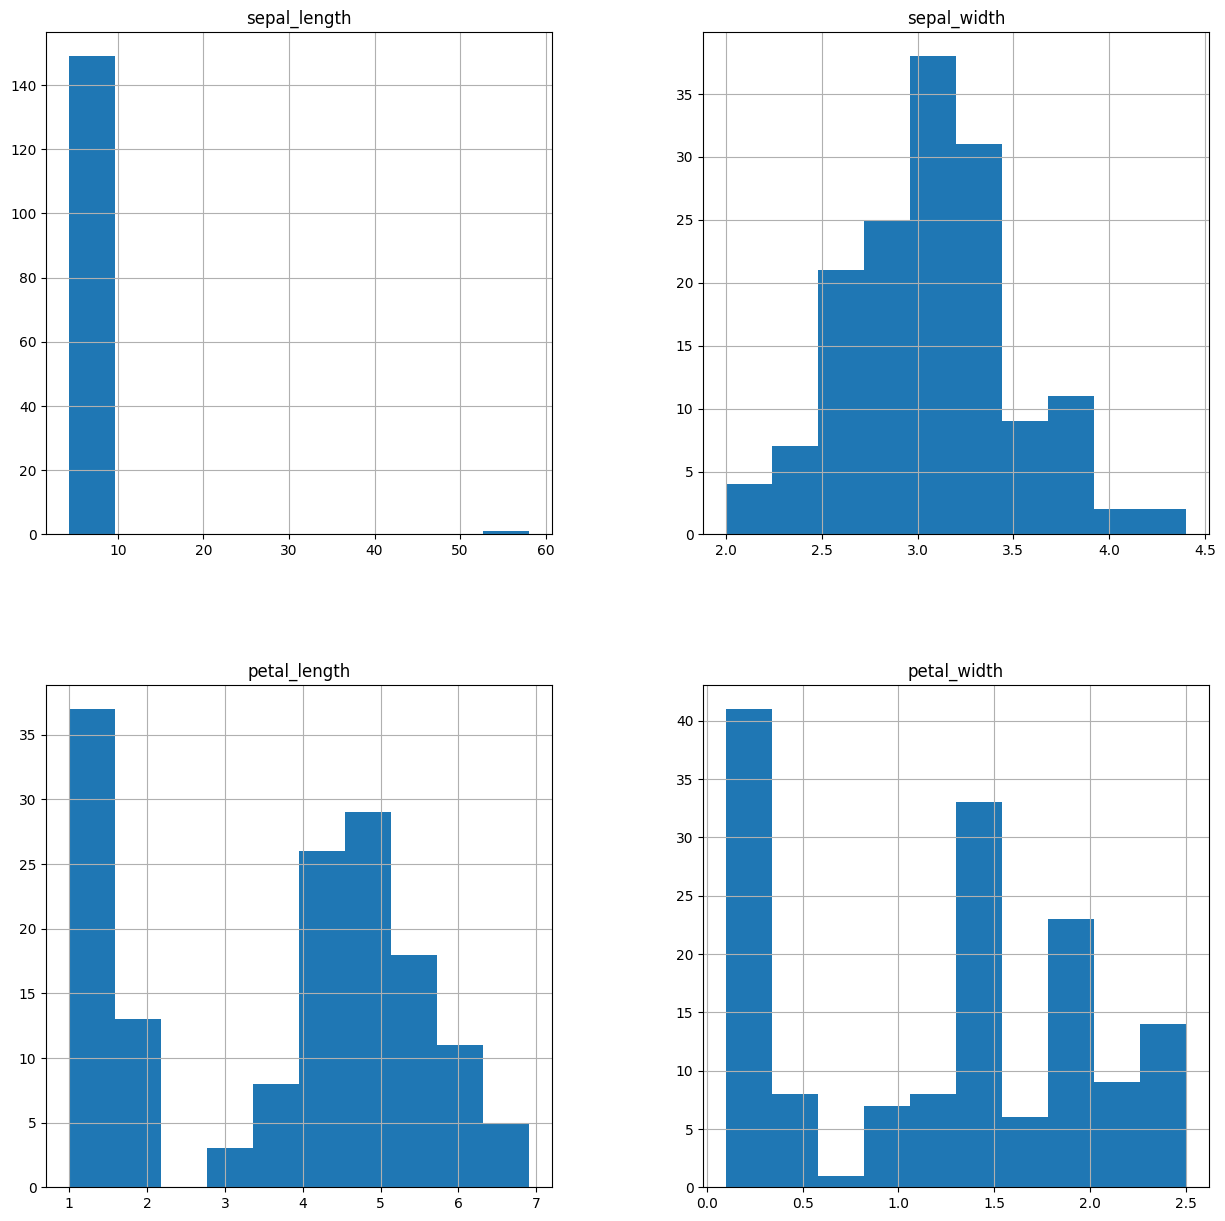

In [225]:
# Histogramm

df.hist(figsize=(15, 15))

In [226]:
# Darstellung des möglichen Ausreißers

df[df["sepal_length"] == 58]

,sepal_length,sepal_width,petal_length,petal_width,class
143,58.0,2.7,5.1,1.9,Iris-virginica


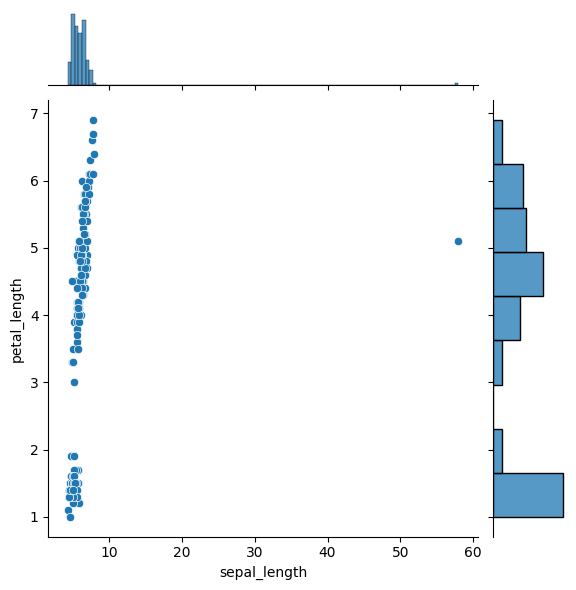

In [227]:
# Untersuchen der Korrelationen

sns.jointplot(x=df['sepal_length'], y=df['petal_length'])

In [228]:
# Korrektur des Werts aufgrund der Korrelation

df.loc[143,'sepal_length'] = 5.8

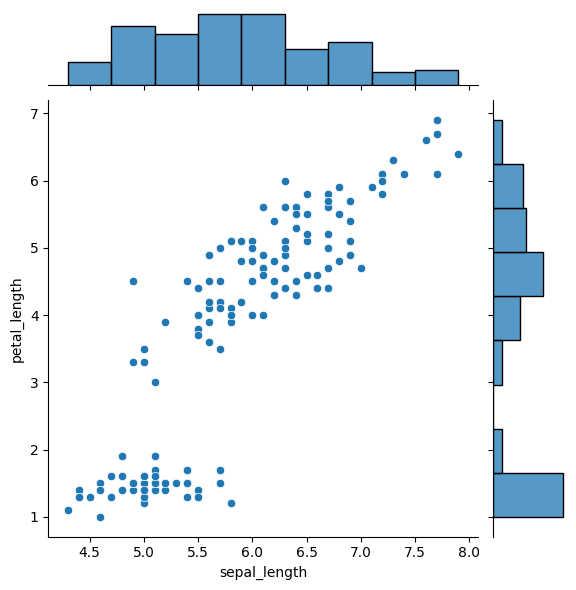

In [229]:
sns.jointplot(x=df['sepal_length'], y=df['petal_length'])

In [230]:
# Korrelationsmatrix zwischen allen Werten: Anpassen des Dataframes

df_corr = df.drop(columns = ["class"])

<Axes: >

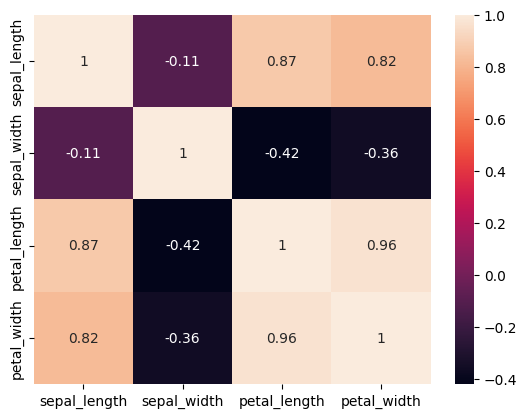

In [231]:
# Korrelationsmatrix anzeigen

corrmat = df_corr.corr()
sns.heatmap(corrmat, annot=True)